In [95]:
# !/usr/bin/env python
import glob
from subprocess import run

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transit_time_dependence_plots import (extract_json, extract_json_tts_filter, extract_json_min_tts_filter, extract_json_tts_chi2_filter,plot_single_transit_time_histogram,
                                           prod_id_to_icm_id,extract_channel,extract_fit_params)

from refit_bad_tt_fits import merge_bins_reduceat
from transit_time_fit_functions import gaussian

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 10})


# colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9','#bc80bd','#ccebc5','#ffed6f','#1f78b4','#33a02c','#e31a1c','#a6cee3','#b2df8a','#fb9a99','#fdbf6f','#ff7f00','#cab2d6','#ffff99','#6a3d9a','#b15928','#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666','#1f78b4']
colorsCustom = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000075", "#F032E6", "#42D4F4", "#FABED4", "#469990", "#DCBEFF", "#9A6324", "#FFFAC8", "#800000", "#AAFFC3", "#808000", "#FFD8B1", "#911EB4", "#3CB44B", "#E6194B", "#8B8682"]


In [96]:
C_msu = 23.9 #ns
C_desy = 25.5 #ns
upgrade_commissioning_scripts = home+"/research_ua/icecube/software/upgrade_commissioning_scripts/"
geometry_files = sorted(glob.glob(upgrade_commissioning_scripts+"/geometry/string_*geometry*.json"))
mdom_tt_dir = home+"/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/"
plotFolder: str = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/mdom_transit"
run_picks_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_run_picks_with_MSU_list.json"
refit_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_tt_needing_refit.json"
empty_meas_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_empty_meas.json"

transit_time_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time.json"
transit_times_single_per_pmt_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_single_pick.json"
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"
# transit_times = extract_json(transit_time_file,obj_key="mu",filter_non_zero=False)
# transit_times_single_per_pmt = extract_json_unique_tt(transit_time_file,run_picks_json,refit_json,empty_meas_json,obj_key="mu",filter_non_zero=True)

In [97]:
from plot_transit_time_single_gaussian import (plot_transit_time_histogram
                                               ,plot_transit_time_spread_histogram,
                                               plot_rse_histogram)

In [ ]:
def extract_json_site(transit_time_file_per_pmt_file,transit_times_single_gaussian_file,site_str,obj_key,filter_non_zero) -> list:
    '''
    Reads the json file with the list of DOMs and transit time measurements and returns a list of transit times
    and other data values
    for chi2, object key : "chi2"
    for transit time, object key:"mu"

    '''
    tt_list = []
    tt_refit_list = []
    tts_list = []
    tts_refit_list = []
    tt_diff_list = []
    tts_diff_list = []
    mdom_worse_fit = []
    chi2_original = []
    chi2_refit = []
    with open(transit_times_single_gaussian_file, 'r') as f:
        data_refit = json.load(f)

    with open(transit_time_file_per_pmt_file, 'r') as f:
        data = json.load(f)
        for mdom, tt_data in data.items():
            if site_str not in mdom:
                continue
            for ichannel in tt_data["transit_times"]:
                for itt in tt_data["transit_times"][ichannel]:
                    if len(itt) > 0 and itt[obj_key] != 0:
                        tt_list.append(itt[obj_key])
                        tts_list.append(itt["sigma"])
                        tt_refit_list.append(data_refit[mdom]["transit_times"][ichannel][0][obj_key])
                        tts_refit_list.append(data_refit[mdom]["transit_times"][ichannel][0]["sigma"])
                        tt_diff_list.append(itt[obj_key] - data_refit[mdom]["transit_times"][ichannel][0][obj_key])
                        tts_diff_list.append(itt["sigma"] - data_refit[mdom]["transit_times"][ichannel][0]["sigma"])
                        chi2_original.append(itt["chi2"])
                        chi2_refit.append(data_refit[mdom]["transit_times"][ichannel][0]["chi2"])
                        if itt["sigma"] - data_refit[mdom]["transit_times"][ichannel][0]["sigma"] < 0:
                        # if (itt["sigma"] - data_refit[mdom]["transit_times"][ichannel][0]["sigma"]) < 0 and data_refit[mdom]["transit_times"][ichannel][0]["chi2"]<5:
                            mdom_worse_fit.append(f"{mdom}_{ichannel}_{itt['run_number']}")
    # print(tt_less_23)
    return tt_list,tt_refit_list,tts_list,tts_refit_list,tt_diff_list,tts_diff_list,mdom_worse_fit, chi2_original, chi2_refit

In [102]:
tt_list_msu,tt_refit_list_msu,tts_list_msu,tts_refit_list_msu,tt_diff_list_msu,tts_diff_list_msu,mdom_worse_fit_msu,chi2_original_msu,chi2_refit_msu = extract_json_site(transit_times_single_per_pmt_file,transit_times_single_gaussian_file,site_str="_M",obj_key="mu",filter_non_zero=False)

In [103]:
tt_list_desy,tt_refit_list_desy,tts_list_desy,tts_refit_list_desy,tt_diff_list_desy,tts_diff_list_desy,mdom_worse_fit_desy,chi2_original_desy,chi2_refit_desy = extract_json_site(transit_times_single_per_pmt_file,transit_times_single_gaussian_file,site_str="_D",obj_key="mu",filter_non_zero=False)

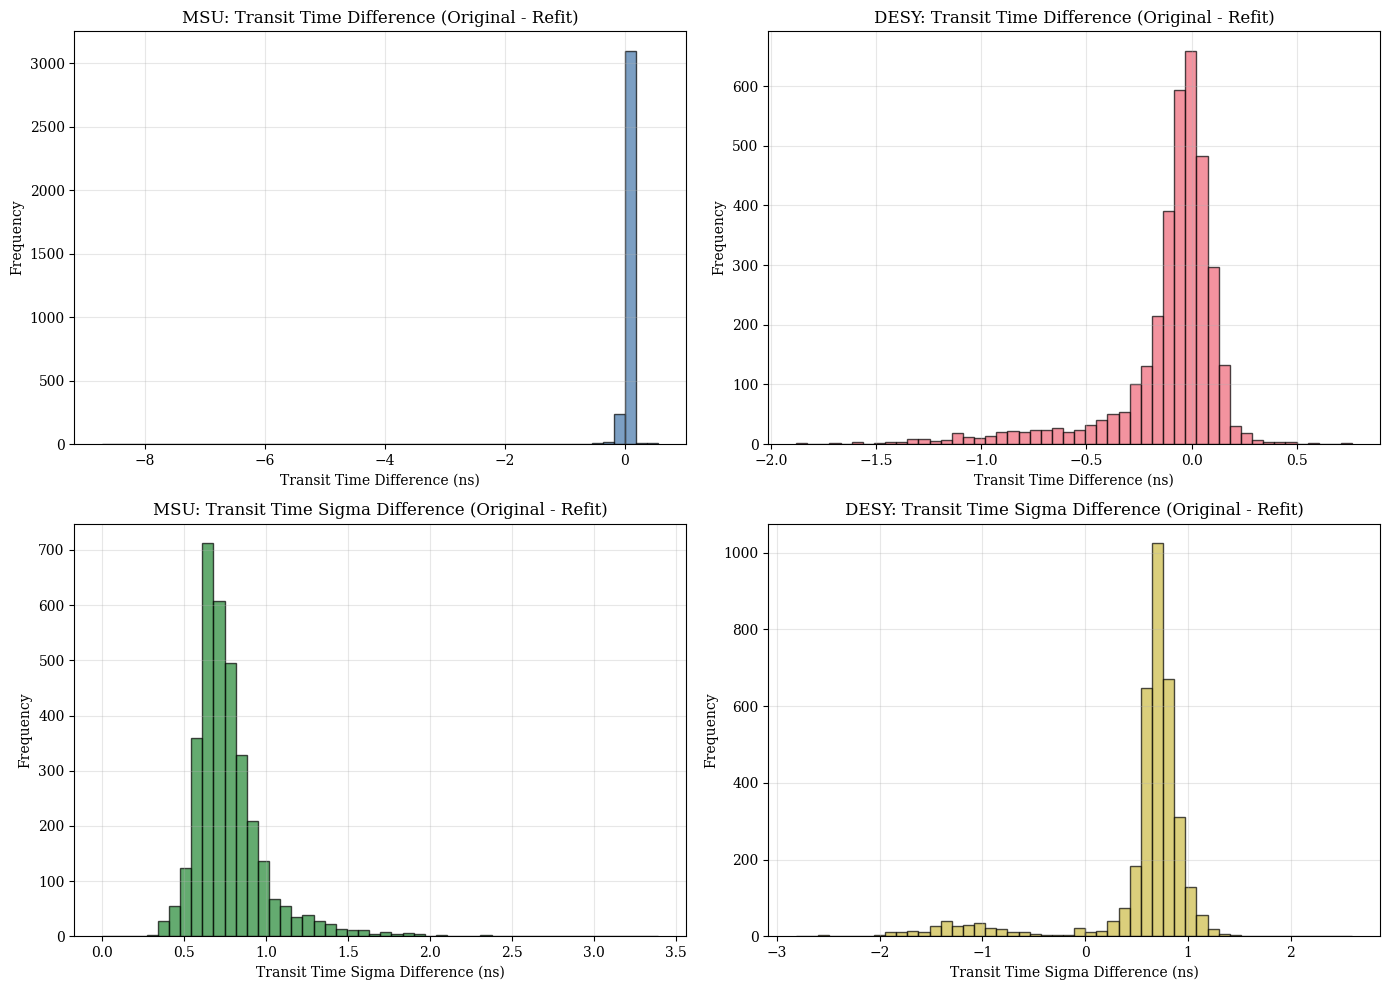

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Transit time difference for MSU
axes[0, 0].hist(tt_diff_list_msu, bins=50, color=colorsCustom[0], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Transit Time Difference (ns)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('MSU: Transit Time Difference (Original - Refit)')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Transit time difference for DESY
axes[0, 1].hist(tt_diff_list_desy, bins=50, color=colorsCustom[1], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Transit Time Difference (ns)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('DESY: Transit Time Difference (Original - Refit)')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Transit time sigma difference for MSU
axes[1, 0].hist(tts_diff_list_msu, bins=50, color=colorsCustom[2], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Transit Time Sigma Difference (ns)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MSU: Transit Time Sigma Difference (Original - Refit)')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Transit time sigma difference for DESY
axes[1, 1].hist(tts_diff_list_desy, bins=50, color=colorsCustom[3], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Transit Time Sigma Difference (ns)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('DESY: Transit Time Sigma Difference (Original - Refit)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plotFolder}/tt_and_tts_differences.png', dpi=300, bbox_inches='tight')
plt.show()

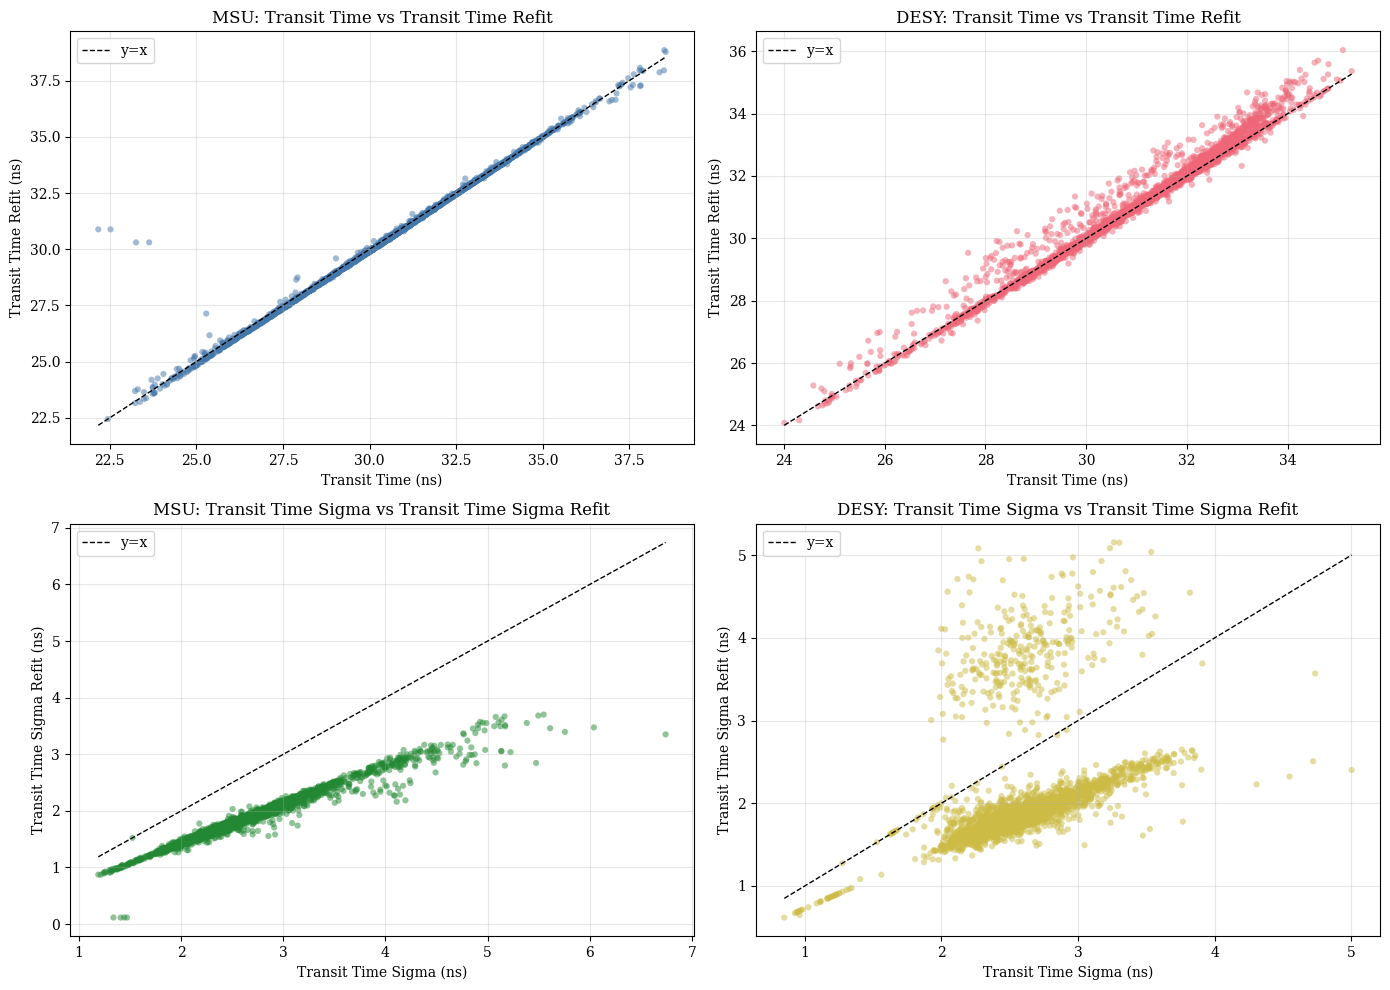

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Transit time vs Transit time refit for MSU
axes[0, 0].scatter(tt_list_msu, tt_refit_list_msu, alpha=0.5, color=colorsCustom[0], s=20, edgecolors='none')
axes[0, 0].plot([min(tt_list_msu), max(tt_list_msu)], [min(tt_list_msu), max(tt_list_msu)], 'k--', lw=1, label='y=x')
axes[0, 0].set_xlabel('Transit Time (ns)')
axes[0, 0].set_ylabel('Transit Time Refit (ns)')
axes[0, 0].set_title('MSU: Transit Time vs Transit Time Refit')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Transit time vs Transit time refit for DESY
axes[0, 1].scatter(tt_list_desy, tt_refit_list_desy, alpha=0.5, color=colorsCustom[1], s=20, edgecolors='none')
axes[0, 1].plot([min(tt_list_desy), max(tt_list_desy)], [min(tt_list_desy), max(tt_list_desy)], 'k--', lw=1, label='y=x')
axes[0, 1].set_xlabel('Transit Time (ns)')
axes[0, 1].set_ylabel('Transit Time Refit (ns)')
axes[0, 1].set_title('DESY: Transit Time vs Transit Time Refit')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Transit time sigma vs Transit time sigma refit for MSU
axes[1, 0].scatter(tts_list_msu, tts_refit_list_msu, alpha=0.5, color=colorsCustom[2], s=20, edgecolors='none')
axes[1, 0].plot([min(tts_list_msu), max(tts_list_msu)], [min(tts_list_msu), max(tts_list_msu)], 'k--', lw=1, label='y=x')
axes[1, 0].set_xlabel('Transit Time Sigma (ns)')
axes[1, 0].set_ylabel('Transit Time Sigma Refit (ns)')
axes[1, 0].set_title('MSU: Transit Time Sigma vs Transit Time Sigma Refit')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Transit time sigma vs Transit time sigma refit for DESY
axes[1, 1].scatter(tts_list_desy, tts_refit_list_desy, alpha=0.5, color=colorsCustom[3], s=20, edgecolors='none')
axes[1, 1].plot([min(tts_list_desy), max(tts_list_desy)], [min(tts_list_desy), max(tts_list_desy)], 'k--', lw=1, label='y=x')
axes[1, 1].set_xlabel('Transit Time Sigma (ns)')
axes[1, 1].set_ylabel('Transit Time Sigma Refit (ns)')
axes[1, 1].set_title('DESY: Transit Time Sigma vs Transit Time Sigma Refit')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plotFolder}/tt_and_tts_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

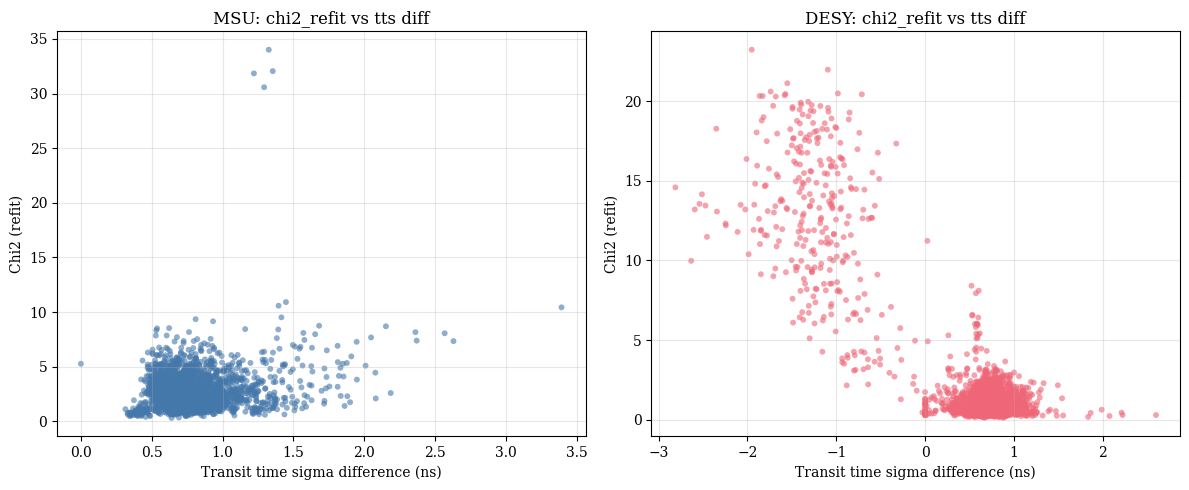

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MSU
ax[0].scatter(tts_diff_list_msu, chi2_refit_msu, s=18, alpha=0.6, color=colorsCustom[0], edgecolors='none')
ax[0].set_xlabel('Transit time sigma difference (ns)')
ax[0].set_ylabel('Chi2 (refit)')
ax[0].set_title('MSU: chi2_refit vs tts diff')
ax[0].grid(alpha=0.3)

# DESY
ax[1].scatter(tts_diff_list_desy, chi2_refit_desy, s=18, alpha=0.6, color=colorsCustom[1], edgecolors='none')
ax[1].set_xlabel('Transit time sigma difference (ns)')
ax[1].set_ylabel('Chi2 (refit)')
ax[1].set_title('DESY: chi2_refit vs tts diff')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plotFolder}/chi2_vs_tts_diff_msu_desy.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mdom_worse_fit_msu

In [92]:
mdom_worse_fit_desy

['mDOM_D068_channel_10_44',
 'mDOM_D039_channel_10_46',
 'mDOM_D029_channel_10_48',
 'mDOM_D090_channel_0_140',
 'mDOM_D090_channel_6_140',
 'mDOM_D090_channel_14_140',
 'mDOM_D090_channel_21_140',
 'mDOM_D036_channel_4_100',
 'mDOM_D067_channel_0_42',
 'mDOM_D084_channel_20_143',
 'mDOM_D211_channel_0_317',
 'mDOM_D211_channel_6_317',
 'mDOM_D211_channel_10_317',
 'mDOM_D211_channel_14_317',
 'mDOM_D211_channel_23_317',
 'mDOM_D007_channel_18_22',
 'mDOM_D034_channel_21_47',
 'mDOM_D206_channel_10_320',
 'mDOM_D092_channel_7_139',
 'mDOM_D030_channel_10_40',
 'mDOM_D020_channel_10_43',
 'mDOM_D054_channel_17_24',
 'mDOM_D015_channel_18_2',
 'mDOM_D015_channel_22_2',
 'mDOM_D070_channel_9_99',
 'mDOM_D196_channel_10_319',
 'mDOM_D199_channel_10_322',
 'mDOM_D208_channel_0_321',
 'mDOM_D208_channel_2_321',
 'mDOM_D208_channel_6_321',
 'mDOM_D208_channel_10_321',
 'mDOM_D208_channel_14_321',
 'mDOM_D208_channel_18_321',
 'mDOM_D208_channel_22_321',
 'mDOM_D208_channel_23_321',
 'mDOM_D20

In [93]:
mdom_json = []
mdom_set = []
for imdom_pmt_run in mdom_worse_fit_desy:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    mdom_json.append({"mDOM":mdom,"channel":channel,"run":run})
    mdom_set.append(mdom)
    print(f"mdom {mdom} channel {channel} run {run}")
# print(set(mdom_set))
print(set(mdom_set))
print(f"{len(mdom_worse_fit_desy)} PMTs {len(set(mdom_set))}")

mdom mDOM_D068 channel 10 run 44
mdom mDOM_D039 channel 10 run 46
mdom mDOM_D029 channel 10 run 48
mdom mDOM_D090 channel 0 run 140
mdom mDOM_D090 channel 6 run 140
mdom mDOM_D090 channel 14 run 140
mdom mDOM_D090 channel 21 run 140
mdom mDOM_D036 channel 4 run 100
mdom mDOM_D067 channel 0 run 42
mdom mDOM_D084 channel 20 run 143
mdom mDOM_D211 channel 0 run 317
mdom mDOM_D211 channel 6 run 317
mdom mDOM_D211 channel 10 run 317
mdom mDOM_D211 channel 14 run 317
mdom mDOM_D211 channel 23 run 317
mdom mDOM_D007 channel 18 run 22
mdom mDOM_D034 channel 21 run 47
mdom mDOM_D206 channel 10 run 320
mdom mDOM_D092 channel 7 run 139
mdom mDOM_D030 channel 10 run 40
mdom mDOM_D020 channel 10 run 43
mdom mDOM_D054 channel 17 run 24
mdom mDOM_D015 channel 18 run 2
mdom mDOM_D015 channel 22 run 2
mdom mDOM_D070 channel 9 run 99
mdom mDOM_D196 channel 10 run 319
mdom mDOM_D199 channel 10 run 322
mdom mDOM_D208 channel 0 run 321
mdom mDOM_D208 channel 2 run 321
mdom mDOM_D208 channel 6 run 321
mdom 

In [94]:
mdom_json

[{'mDOM': 'mDOM_D068', 'channel': '10', 'run': '44'},
 {'mDOM': 'mDOM_D039', 'channel': '10', 'run': '46'},
 {'mDOM': 'mDOM_D029', 'channel': '10', 'run': '48'},
 {'mDOM': 'mDOM_D090', 'channel': '0', 'run': '140'},
 {'mDOM': 'mDOM_D090', 'channel': '6', 'run': '140'},
 {'mDOM': 'mDOM_D090', 'channel': '14', 'run': '140'},
 {'mDOM': 'mDOM_D090', 'channel': '21', 'run': '140'},
 {'mDOM': 'mDOM_D036', 'channel': '4', 'run': '100'},
 {'mDOM': 'mDOM_D067', 'channel': '0', 'run': '42'},
 {'mDOM': 'mDOM_D084', 'channel': '20', 'run': '143'},
 {'mDOM': 'mDOM_D211', 'channel': '0', 'run': '317'},
 {'mDOM': 'mDOM_D211', 'channel': '6', 'run': '317'},
 {'mDOM': 'mDOM_D211', 'channel': '10', 'run': '317'},
 {'mDOM': 'mDOM_D211', 'channel': '14', 'run': '317'},
 {'mDOM': 'mDOM_D211', 'channel': '23', 'run': '317'},
 {'mDOM': 'mDOM_D007', 'channel': '18', 'run': '22'},
 {'mDOM': 'mDOM_D034', 'channel': '21', 'run': '47'},
 {'mDOM': 'mDOM_D206', 'channel': '10', 'run': '320'},
 {'mDOM': 'mDOM_D092',